<div style="border:solid green 3px; padding: 20px">
																							
<b>Привет, Сауле!</b>
																					
Меня зовут Сороколетов Илья и я буду проверять твой проект. 
																					
Предлагаю общаться на «**ты**», но если тебе будет комфортнее общаться на «**вы**», то сообщи об этом в комментариях)
																					
																					
Для твоего удобства, я буду выделять свои комментарии следующим образом:
																					
<div class="alert alert-danger">
<b>❌ Комментарий ревьюера v1:</b> Самые важные замечания. Они указывают на ключевые моменты, которые влияют на конечный результат проекта. </div>
																					
<div class="alert alert-warning">
<b>⚠️ Комментарий ревьюера v1:</b> Советы или замечания, которые помогут сделать твою работу лучше, но необязательны к выполнению.
																					
</div>
																					
<div class="alert alert-success">
<b>✔️ Комментарий ревьюера v1:</b> Так я выделяю все остальные комментарии.</div>
																					
																					
Пометками <b>v1-v2-v3-...</b> я буду отмечать версию проверки. Так ты сможешь быстро найти мои новые комментарии.
																					
Давай работать над проектом в диалоге: если ты что-то меняешь в проекте по моим рекомендациям — пиши об этом. Выбери для своих комментариев какой-то заметный цвет, так мне будет легче отследить изменения, например вот так:
																					    
<div class="alert alert-info">
<b>Комментарий студента:</b>
<br>
</div>
																					
<b>Пожалуйста, не перемещай, не изменяй и не удаляй мои комментарии.</b> Если ты оставляешь свои комментарии, то делай это под моими, чтобы сообщения были расположены в хронологическом порядке. Всё это поможет выполнить повторную проверку твоего проекта быстрее. 
																					
Перед отправкой работы я рекомендую нажимать Kernel -> Restart & Run All. Это перезапустит ядро и по очереди выполнит все ячейки. Так ты сможешь проверить, что всё работает корректно. Кнопка Kernel находится в панели сверху
																					
Обязательно задавай вопросы если они возникнут, а я перехожу к проверке)
																					
P.S. На всякий случай, я оставлю пустой шаблон для твоих комментариев ниже. Кликни два раза на мой комментарий, скопируй последние четыре строчки кода и вставляй их в пустую ячейку там, где ты хочешь оставить комментарий. Не забудь только перед этим сменить тип ячейки на Markdown. Быстро это можно сделать так: кликнуть на ячейку - нажать ESC - нажать M. 
																					    
																					    
<div class="alert alert-info">
<b>Комментарий студента:</b>
<br>Удали этот текст и вместо него напиши свой комментарий 🙂
</div>

# Часть 1. Проверка гипотезы в Python и составление аналитической записки

Вы предобработали данные в SQL, и теперь они готовы для проверки гипотезы в Python. Загрузите данные пользователей из Москвы и Санкт-Петербурга c суммой часов их активности из файла yandex_knigi_data.csv. Если работаете локально, скачать файл можно по ссылке.

Проверьте наличие дубликатов в идентификаторах пользователей. Сравните размеры групп, их статистики и распределение.

Напомним, как выглядит гипотеза: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

Нулевая гипотеза $H_0: \mu_{\text{СПб}} \leq \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге не больше, чем в Москве.

Альтернативная гипотеза $H_1: \mu_{\text{СПб}} > \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

По результатам анализа данных подготовьте аналитическую записку, в которой опишите:

Выбранный тип t-теста и уровень статистической значимости.

Результат теста, или p-value.

Вывод на основе полученного p-value, то есть интерпретацию результатов.

Одну или две возможные причины, объясняющие полученные результаты.

##  1. Проверка гипотезы в Python и составление аналитической записки

- Автор: Bayekina Saule 
- Дата: 21.09.2026

## Цели и задачи проекта

   - Цель проекта: проверить гипотезу о том, что пользователи из Санкт-Петербурга в среднем проводят больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы.
   - Задача: проверка статистической гипотезы на двух независимых выборках (или «сравнительный анализ»)

## Описание данных
- `city` — город пользователя;
- `puid` — идентификатор пользователя;
- `hours` — общее количество часов активности 


## Содержимое проекта

 - Загрузка данных и знакомство с ними
 - Проверка дубликатов
 - Сравнение групп
 - Проверка равенства дисперсий
 - Проверка гипотезы в Python
 - Аналитическая записка


## 1. Загрузка данных и знакомство с ними

Загрузите данные пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания) из файла `/datasets/yandex_knigi_data.csv`.

In [1]:
# Загружаем библиотеки 
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportions_ztest

<div class="alert alert-success">
<b>✔️ Комментарий ревьюера v1:</b> 
<br>Ты правильно делаешь, что импортируешь все библиотеки отдельно в первой ячейке. Это правило хорошего тона, которое позволит твоим коллегам сразу увидеть все необходимые библиотеки для работы с твоим файлом.
</div>

In [2]:
# # Выгружаем данные в переменую df
df=pd.read_csv('/datasets/yandex_knigi_data.csv')

Познакомимся с данными датасета df — выведем первые строки методом head(), а информацию о датафрейме методом info():

In [3]:
# Выводим первые строки датафрейма на экран
df.head()

,Unnamed: 0,city,puid,hours
0,0,Москва,9668,26.167776
1,1,Москва,16598,82.111217
2,2,Москва,80401,4.656906
3,3,Москва,140205,1.840556
4,4,Москва,248755,151.326434


In [4]:
# Выводим информацию о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  8784 non-null   int64  
 1   city        8784 non-null   object 
 2   puid        8784 non-null   int64  
 3   hours       8784 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 274.6+ KB


Датасет df содержит 8784 строк и 4 столбцов, в них хранятся информация о пользователях, их городах и часах активности.

- В датасете представлены три типа данных — 1 столбец с плавающей точкой (float64) и 2 столбца с целочисленным типом int64, 1 столбец с типом object.
- Пропуски отсутствуют
- Необходимо проверить наличие дубликатов


## 2. Проверка дубликатов


In [5]:
# Проверим полные дубликаты в df
df.duplicated().sum()

0

In [43]:
df['puid'].duplicated().sum()

244

Дубликатов не обнаружено

<div class="alert alert-danger"><b>❌ Комментарий ревьюера v1:</b><br>Проверка полных дубликатов не заменяет проверку повторений в идентификаторах пользователей. Одинаковый puid может находиться в нескольких строках с разными городами и значениями активности, поэтому такие строки не будут полными дубликатами.<br>Проверь повторения по puid, изучи, в каких городах встречаются эти пользователи, и сформируй независимые городские группы. После очистки необходимо пересчитать размеры групп, описательные статистики, график, проверку дисперсий и t-тест.</div>

<div class="alert alert-info">
<b>Комментарий студента:</b>
<br>Удали этот текст и вместо него напиши свой комментарий 🙂
</div>

## 3. Сравнение групп


In [6]:
df['city'].value_counts()

Москва             6234
Санкт-Петербург    2550
Name: city, dtype: int64

В Москве пользователей почти в 2.5 раза больше 6234 чем в Санкт-Петербурге 2550.

Теперь статистики — сравним среднее, медиану и стандартное отклонение по каждой группе:

In [7]:
df.groupby('city')['hours'].describe()

,count,mean,std,min,25%,50%,75%,max
city,,,,,,,,
Москва,6234.0,10.881092,36.851683,0.000018,0.059903,0.924498,5.939972,857.209373
Санкт-Петербург,2550.0,11.592691,39.704993,0.000025,0.080002,0.984781,6.509072,978.764775


- Среднее (mean) намного больше медианы (50%) в обеих группах: Москва — 10.88 против 0.92, СПб — 11.59 против 0.98. 
- Это значит, что распределение сильно скошено вправо: типичный пользователь читает/слушает меньше часа, но есть небольшая группа очень активных пользователей, которая тянет среднее вверх.
- Максимумы огромные (857 и 978 часов) — это выбросы, из-за которых std тоже раздутый.

Посмотрим распределение, визуально, на одном графике сразу для обеих групп:

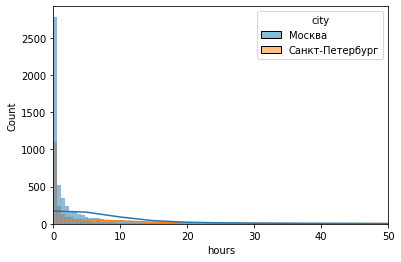

In [8]:
sns.histplot(data=df, x='hours', hue='city', kde=True)
plt.xlim(0, 50)  
plt.show()

<div class="alert alert-success"><b>✔️ Комментарий ревьюера v1:</b><br>Совместная гистограмма позволяет наглядно сравнить форму распределений при одинаковых интервалах. Ограничение оси помогает рассмотреть основную массу наблюдений, не удаляя наиболее активных пользователей из данных. </div>

Распределения похожи по форме в обеих группах — сильно скошены вправо: основная масса пользователей группируется у 0–5 часов, дальше идёт длинный хвост редких, но очень активных пользователей. По форме Москва и СПб выглядят похоже, просто у Москвы абсолютные числа выше (больше пользователей).

## 4. Проверка равенства дисперсий

In [9]:
group_moscow = df[df['city'] == 'Москва']['hours']
group_spb = df[df['city'] == 'Санкт-Петербург']['hours']

stats.levene(group_moscow, group_spb)

LeveneResult(statistic=0.60611624217368, pvalue=0.4362748478542563)

p-value = 0.436, что намного больше 0.05 — значит, дисперсии групп статистически значимо не отличаются. Вывод: можно использовать обычный t-тест

<div class="alert alert-warning"><b>⚠️ Комментарий ревьюера v1:</b><br>Тест Левена не выявил статистически значимого различия дисперсий, поэтому применение t-теста Стьюдента можно обосновать. Однако большое p-value не доказывает равенство дисперсий. При заметно различающихся размерах групп тест Уэлча остаётся более устойчивым вариантом и не требует предварительного предположения о равенстве дисперсий.</div>

## 5. Проверка гипотезы в Python


Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [10]:
alpha = 0.05  # уровень значимости
results = stats.ttest_ind(group_spb, group_moscow, equal_var=True, alternative='greater')

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу: разница статистически значима')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

p-value: 0.21101894136116772
Не получилось отвергнуть нулевую гипотезу


Результат: p-value = 0.211, что больше α = 0.05 → не удалось отвергнуть H₀. Статистически значимых доказательств того, что пользователи из Санкт-Петербурга в среднем проводят больше времени в приложении, чем пользователи из Москвы, у нас нет.

<div class="alert alert-success"><b>✔️ Комментарий ревьюера v1:</b><br>Направление теста задано верно: при порядке выборок «Санкт-Петербург, Москва» параметр `alternative='greater'` проверяет, выше ли средняя активность в Санкт-Петербурге. Вывод также сформулирован аккуратно: гипотезу не удалось подтвердить, а не доказано равенство городов.</div>

## 6. Аналитическая записка
По результатам анализа данных подготовьте аналитическую записку, в которой опишете:

- Тип теста: односторонний t-тест для двух независимых выборок (equal_var=True, alternative='greater'), т.к. тест Ливиня показал отсутствие значимых различий в дисперсиях (p=0.436).

- Уровень значимости α = 0.05.

- Результат: p-value = 0.211.

- Вывод: т.к. p-value > α, нулевая гипотеза не отвергается — статистически значимой разницы в среднем времени активности между городами не выявлено.

Возможные причины :

- LTV — это про деньги, а не про время: разница в LTV между городами могла возникнуть не из-за того, что питерцы дольше читают, а из-за того, что они, например, чаще выбирают более дорогую подписку или платят больше за единицу времени. Время активности и выручка — разные метрики, и они не обязаны коррелировать напрямую.
- Само распределение очень скошено  — большинство пользователей мало активны, а разницу "тянут" редкие супер-активные пользователи. При такой высокой изменчивости данных даже реальная небольшая разница между городами может "потеряться" на фоне общего разброса и не набрать статистической значимости.



----

# Часть 2. Анализ результатов A/B-тестирования

Теперь вам нужно проанализировать другие данные. Представьте, что к вам обратились представители интернет-магазина BitMotion Kit, в котором продаются геймифицированные товары для тех, кто ведёт здоровый образ жизни. У него есть своя целевая аудитория, даже появились хиты продаж: эспандер со счётчиком и напоминанием, так и подстольный велотренажёр с Bluetooth.

В будущем компания хочет расширить ассортимент товаров. Но перед этим нужно решить одну проблему. Интерфейс онлайн-магазина слишком сложен для пользователей — об этом говорят отзывы.

Чтобы привлечь новых клиентов и увеличить число продаж, владельцы магазина разработали новую версию сайта и протестировали его на части пользователей. По задумке, это решение доказуемо повысит количество пользователей, которые совершат покупку.

Ваша задача — провести оценку результатов A/B-теста. В вашем распоряжении:

* данные о действиях пользователей и распределении их на группы,

* техническое задание.

Оцените корректность проведения теста и проанализируйте его результаты.

## 1. Опишите цели исследования.



Цель исследования — проанализировать данные о действиях пользователей, разделённых на группы A и B, чтобы проверить гипотезу: приводит ли новая версия сайта (тестируемая на группе B) к увеличению доли пользователей, совершающих покупку, по сравнению со старой версией (группа A). Дополнительно — оценить корректность проведения A/B-теста и проанализировать его результаты.

## 2. Загрузите данные, оцените их целостность.


In [11]:
# Загружаем таблицы участников теста и событий
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

Познакомимся с данными датасета `participants` — выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [12]:
# Выводим первые строки датафрейма на экран
participants.head()

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


In [13]:
# Выводим информацию о датафрейме
participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


In [14]:
# Проверим полные дубликаты в participants
participants.duplicated().sum()

0

Датасет `participants` содержит 4 столбца и 14525 строк,в которых содержится информация о пользователях групп А и В,об усройствах пользователей и названиях теста. В данных нет пропусков и дубликатов.

Теперь познакомимся с данными датасета `events` - также выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [15]:
# Выводим первые строки датафрейма на экран
events.head()

,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


In [16]:
# Выводим информацию о датафрейме
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


Датасет `events` содержит 4 столбца и 787286 строк,  в них хранятся информация о событиях. Типы данных корректны. есть пропуски в столбце details,это скорее особенность структуры данных, а не "грязные" данные, которые надо чистить. Необходимо проверить наличие дубликатов. 

In [17]:
# Проверим полные дубликаты в events
events.duplicated().sum()

36318

In [18]:
# Удалим явные дубликаты
events=events.drop_duplicates()

<div class="alert alert-success"><b>✔️ Комментарий ревьюера v1:</b><br>Полные дубликаты событий обнаружены и удалены до анализа активности. Это особенно важно для подсчёта количества событий: повторные строки больше не завышают их частоту.</div>

In [19]:
# Проверим, сколько строк осталось
events.shape[0]

750968

В датасете events было обнаружено 36318 явных дубликатов,для корректности дальнейшего анализа удалили дубликаты

In [20]:
 # Посмотрим уникальные значения в столбц event_name
    
target_cols = ['event_name']

for col in target_cols:
    print(f"Уникальные значения в столбце '{col}':")
    print(events[col].unique())
    print("-" * 40)

    

Уникальные значения в столбце 'event_name':
['End of Black Friday Ads Campaign' 'registration' 'product_page' 'login'
 'product_cart' 'purchase' 'Start of Christmas&New Year Promo'
 'Start of CIS New Year Gift Lottery']
----------------------------------------


В столбце `event_name` представлены события пользовательской воронки (`registration` → `login` → `product_page` → `product_cart` → `purchase`) и события рекламных кампаний (`Black Friday`, `Christmas&New Year Promo`, `CIS New Year Lottery`). Проверим, какие события относятся к глобальным, а какие — к отдельным пользователям.

In [21]:
# Посмотрим события, которые имеют user_id = 'GLOBAL'
events[events['user_id'] == 'GLOBAL']['event_name'].unique()


array(['End of Black Friday Ads Campaign', 'product_page', 'product_cart',
       'purchase', 'Start of Christmas&New Year Promo',
       'Start of CIS New Year Gift Lottery'], dtype=object)

In [22]:
# Посмотрим события, которые относятся к конкретным пользователям
events[events['user_id'] != 'GLOBAL']['event_name'].unique()


array(['registration', 'login', 'product_page', 'product_cart',
       'purchase'], dtype=object)

In [23]:
# Посмотрим, как часто встречается каждое событие у GLOBAL
events[events['user_id'] == 'GLOBAL']['event_name'].value_counts()

product_page                          32583
purchase                              15325
product_cart                           9739
Start of CIS New Year Gift Lottery        1
Start of Christmas&New Year Promo         1
End of Black Friday Ads Campaign          1
Name: event_name, dtype: int64

В результате видим:
- События, которые бывают только у пользователей с конкретным user_id (registration, login) 
- События, которые бывают и у реальных user_id, и у GLOBAL (product_page, product_cart, purchase)
- События, которые бывают только у GLOBAL (3 рекламные кампании)
--------
Для user_id = GLOBAL чаще всего встречаются события product_page (32 583), purchase (15 325) и product_cart (9 739). Три события рекламных кампаний встречаются по одному разу. Таким образом, GLOBAL используется не только для рекламных событий: с ним также связаны основные события воронки. Поэтому GLOBAL нельзя однозначно интерпретировать как отдельного пользователя или как признак незарегистрированного пользователя.

In [24]:
#  Посмотрим диапазон дат в event_dt — с какого по какое число фактически есть данные 
min_date = events['event_dt'].min()
max_date = events['event_dt'].max()

print(f"Данные начинаются с: {min_date.strftime('%Y-%m-%d')}")
print(f"Данные заканчиваются: {max_date.strftime('%Y-%m-%d')}")
print(f"Всего дней в диапазоне: {(max_date - min_date).days}")


Данные начинаются с: 2020-12-01
Данные заканчиваются: 2020-12-31
Всего дней в диапазоне: 30


## 3. По таблице `ab_test_participants` оцените корректность проведения теста:

   3\.1 Выделите пользователей, участвующих в тесте, и проверьте:

   - соответствие требованиям технического задания,

   - равномерность распределения пользователей по группам теста,

   - отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах).

In [25]:
# 1. Сохраняем срез таблицы в df_test 
df_test = participants[participants['ab_test'] == 'interface_eu_test']

# 2. Считаем количество уникальных пользователей внутри этого среза
users_count = df_test['user_id'].nunique()
print(f"Количество уникальных пользователей в тесте: {users_count}")

Количество уникальных пользователей в тесте: 10850


In [26]:
# Расчитаем кол-во уникальных пользователей в группах
df_test[df_test['group']=='A']['user_id'].nunique(),df_test[df_test['group']=='B']['user_id'].nunique()

(5383, 5467)

Равномерность распределения —  всё сходится с общим числом участников теста. Разница между группами минимальная (49.6% / 50.4%) — распределение равномерное

In [27]:
# Проверим пользователей которые могли попасть в обе группы
A=df_test[df_test['group']=='A']['user_id']
B=df_test[df_test['group']=='B']['user_id']
intersection_group=list(set(A)&set(B))
print(intersection_group)

[]


Пересечений между группами А и В нет

In [28]:
# Проверим пользователей которые могли попасть в нескоько тестовых группы

interface_eu_test=participants[participants['ab_test']=='interface_eu_test']['user_id']
recommender_system_test=participants[participants['ab_test']=='recommender_system_test']['user_id']
intersection_ab_test=list(set(interface_eu_test)&set(recommender_system_test))
print(intersection_ab_test)

['8FF91E21E27A330D', '902F92052587344F', 'B6E4E414699EFC1F', 'E0EEE04D9FDB4931', 'E391353FC3A4056D', 'DA8DABF19A0203FD', 'EEA592D3C6F5E5A4', 'C86F0150DA3B10F2', '2FCC63EB9CB798BF', '36EDA624DB7B7F90', 'A09DFE27D4CFF8E8', '8FC9D1BB3017BE66', '502902B3C32C72FF', '3D264F3D953DBA67', '739656E0D7B50B30', 'B27B9689064C54C4', 'B150C94FFD64D8B0', 'D9BAC4C97F9C107F', '1FA7A8399291885E', 'C0DDE3AA2A89024F', '0F13D8C2809AD613', 'C72752E18AD12854', '16F2DB656CC2F952', 'C615792E479BC0C8', '8FF8F87305BB9A7D', 'C5AE17CBD0B33628', 'B931BC5D6FE1416C', '8F72F2114F2D5184', '0363BAFB478AA9EF', '69E475C5708ABE56', '4CCE583A34A8362C', '220C8F0BE40515E5', 'A352755099619F01', 'C573C24EF423143C', 'D1D7C0CCE823D871', '52EC082510DA513B', '0ACD764342811460', 'E68002AA33773AD5', '2B06EB547B7AAD08', '74285DE881A72F4C', '2787953F22AA5648', 'E17D1ABC377C38CA', 'ED61DF6AA1B81F5B', '3AA908B2D4A96AC2', '64D18CAEAEE6150A', '549A5092FD1BD5D9', '2CDFC246EAEEAB13', 'E77F99BCF9D8AB96', '9BD9E79856D54059', '9431D6C9475CFD3A',

Между тестами `interface_eu_test` и `recommender_system_test` есть пользователи, которые участвуют в обоих одновременно. Посмотрим, какую долю от общего числа участников `interface_eu_test` составляют такие пользователи.


In [29]:
# Доля пользователей, участвующих в обоих тестах одновременно
100*len(intersection_ab_test)/len(interface_eu_test)

8.175115207373272

Доля пересечения составила `8.18%` (887 пользователей) от участников `interface_eu_test`

Проверка корректности теста `interface_eu_test` дала следующие результаты. Количество уникальных участников теста — `10850` человек. Распределение по группам оказалось равномерным: `5383` в группе `A` против `5467` в группе `B`. Пересечений между группами `A` и `B` внутри самого `interface_eu_test` не обнаружено — ни один пользователь не попал в обе группы одновременно. Однако выявлено пересечение с конкурирующим тестом `recommender_system_test``: 887 пользователей` (`8.18%` от участников `interface_eu_test`) участвовали в обоих тестах одновременно. Чтобы избежать искажения результатов на следующих этапах анализа, эти пользователи будут исключены из выборки.

In [30]:
# Убираем из выборки пользователей, попавших в оба теста
df_test=df_test[~df_test['user_id'].isin(intersection_ab_test)]
df_test['user_id'].nunique()

9963

<div class="alert alert-warning"><b>⚠️ Комментарий ревьюера v1:</b><br>Разность между крайними датами равна числу прошедших суток, а не числу календарных дат в журнале. Поэтому здесь понятнее оставить даты начала и окончания либо отдельно посчитать количество уникальных календарных дней.</div>

3\.2 Проанализируйте данные о пользовательской активности по таблице `ab_test_events`:

- оставьте только события, связанные с участвующими в изучаемом тесте пользователями;

In [31]:
#Сохраним в переменную events_test события, связанные с участвующими в изучаемом тесте `interface_eu_test`
# пользователями
events_test = events[ events['user_id'].isin(df_test['user_id'])]

In [32]:
# Сравним ушли ли строки, и события людей, не участвующих в interface_eu_test

print(f"Количество событий до фильтрации: {events.shape[0]}\n"
      f"Количество событий после фильтрации: {events_test.shape[0]}")

Количество событий до фильтрации: 750968
Количество событий после фильтрации: 68074


- определите горизонт анализа: рассчитайте время (лайфтайм) совершения события пользователем после регистрации и оставьте только те события, которые были выполнены в течение первых семи дней с момента регистрации;

In [33]:
# Достаём дату регистрации каждого пользователя и переименовываем колонку
registration_users = events_test[events_test.event_name == 'registration'][['user_id', 'event_dt']]
registration_users=registration_users.rename(columns={'event_dt':'registration_dt'})
registration_users.columns

Index(['user_id', 'registration_dt'], dtype='object')

In [34]:
# Присоединяем дату регистрации к каждому событию пользователя
events_lifetime=registration_users.merge(events_test,how='inner', on='user_id') 
events_lifetime.shape[0]

68074

In [35]:
# Считаем, сколько времени прошло между регистрацией и событием
time_delta=events_lifetime.event_dt-events_lifetime.registration_dt
time_delta.head()

0   0 days 00:00:00
1   0 days 11:15:13
2   0 days 11:15:46
3   2 days 22:30:48
4   2 days 22:30:48
dtype: timedelta64[ns]

In [36]:
# Оставляем события, выполненные в течение первых 7 дней (от 0 до 7 дней включительно)
lifetime_after_reg = events_lifetime.loc[
    (time_delta >= pd.Timedelta(days=0)) & 
    (time_delta< pd.Timedelta(days=7))
]
lifetime_after_reg.shape[0]

58692

<div class="alert alert-success"><b>✔️ Комментарий ревьюера v1:</b><br>Семидневное окно рассчитано от точного времени регистрации каждого пользователя. Условия от нуля включительно до семи суток не включительно соответствуют первым семи полным суткам после регистрации.</div> 

<div class="alert alert-warning"><b>⚠️ Комментарий ревьюера v1:</b><br>Дополнительно проверь полноту окна наблюдения: сопоставь время последней регистрации участников с окончанием журнала событий. Это подтвердит, что для поздно зарегистрировавшихся пользователей тоже доступны все семь суток.</div>

In [37]:
lifetime_after_reg[['user_id','event_dt','registration_dt']].head()

,user_id,event_dt,registration_dt
0,5F506CEBEDC05D30,2020-12-06 14:10:01,2020-12-06 14:10:01
1,5F506CEBEDC05D30,2020-12-07 01:25:14,2020-12-06 14:10:01
2,5F506CEBEDC05D30,2020-12-07 01:25:47,2020-12-06 14:10:01
3,5F506CEBEDC05D30,2020-12-09 12:40:49,2020-12-06 14:10:01
4,5F506CEBEDC05D30,2020-12-09 12:40:49,2020-12-06 14:10:01


Оцените достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

In [38]:
# Расчитаем размер выборки
# Зададим параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 0.8  # Мощность теста
p = 0.3  # Базовый уровень доли
mde = p + 0.03 # рост как минимум на 3 п.п.
effect_size = proportion_effectsize(p, mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 3761


<div class="alert alert-warning"><b>⚠️ Комментарий ревьюера v1:</b><br>Переход от базовой конверсии к приросту на 3 процентных пункта задан верно. Необходимый размер выборки следует округлять вверх: `int()` просто отбрасывает дробную часть. Также поясни, что расчёт выполнен для двустороннего критерия по умолчанию, тогда как итоговый Z-тест односторонний; такой расчёт даёт более консервативное требование.</div>

- рассчитайте для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

In [39]:
# Соединяем df_test содержащий данные 'interface_eu_test' и lifetime_after_reg событиями,выполненные в течение первых 7 дней
merge_df=df_test.merge(lifetime_after_reg,how='inner', on='user_id') 
merge_df.shape[0]

58692

In [40]:
# Считаем по группам: всего пользователей, купивших и конверсию
count_user=merge_df.groupby('group')['user_id'].nunique()
purchases_only = merge_df[merge_df['event_name'] == 'purchase']
count_buyers = purchases_only.groupby('group')['user_id'].nunique()
total_table=pd.DataFrame({'count_user':count_user,'count_buyers':count_buyers,'ratio':count_buyers / count_user})
total_table

,count_user,count_buyers,ratio
group,,,
A,4952,1377,0.278069
B,5011,1480,0.295350


- сделайте предварительный общий вывод об изменении пользовательской активности в тестовой группе по сравнению с контрольной.

Гипотеза теста заключалась в том, что упрощение интерфейса приведёт к росту конверсии зарегистрированных пользователей в покупателей минимум на 3 процентных пункта (с 30% до 33%) в течение первых семи дней после регистрации.

По фактическим данным конверсия в контрольной группе A составила 27.8%, в тестовой группе B (новый интерфейс) — 29.5%. Разница составила 1.73 процентных пункта, что заметно меньше заявленных в гипотезе 3 п.п. Кроме того, базовая конверсия контрольной группы (27.8%) оказалась ниже той, что была указана в техническом задании (30%).

Предварительно можно предположить, что заявленный эффект теста не подтверждается в полном объёме. Однако делать окончательный вывод пока рано — обнаруженная разница в 1.73 п.п. может оказаться статистически незначимой (случайным шумом), а не реальным эффектом от нового интерфейса. Точный ответ даст статистический тест

<div class="alert alert-success"><b>✔️ Комментарий ревьюера v1:</b><br>Конверсии рассчитаны по уникальным покупателям за первые семь дней, а наблюдаемый эффект корректно выражен в процентных пунктах. Молодец!</div>

## 4. Проведите оценку результатов A/B-тестирования:

- Проверьте изменение конверсии подходящим статистическим тестом, учитывая все этапы проверки гипотез.

In [41]:
nobs_a=count_user['A']
nobs_b=count_user['B']
count_a=count_buyers['A']
count_b=count_buyers['B']
p_a,p_b=count_a/nobs_a,count_b/nobs_b
if (p_a*nobs_a>10) and ((1-p_a)*nobs_a>10) and (p_b*nobs_b>10) and ((1-p_b)*nobs_b>10):
    print('выборки достаточно велики для применения z-теста')
else:
    print('выборки слишком малы, z-тест может быть неточным')

# Уровеень значимости
alpha=0.05

# Z-тест для сравнения долей ...между группами A и B
stat_ztest,p_value_ztest=proportions_ztest(
    [count_b,count_a],
    [nobs_b,nobs_a],
    alternative='larger')
print(f'pvale={p_value_ztest}')


выборки достаточно велики для применения z-теста
pvale=0.028262547212292124


Сравним результат, p-value = 0.0283 с α = 0.05: 
p-value < alpha → нулевая гипотеза отвергается.

- Опишите выводы по проведённой оценке результатов A/B-тестирования. Что можно сказать про результаты A/B-тестирования? Был ли достигнут ожидаемый эффект в изменении конверсии?

Статистическая проверка показала, что нулевая гипотеза (различий между группами нет) отвергается: рост конверсии в тестовой группе B статистически значим (p-value = 0.028 < α = 0.05) и не объясняется случайностью.

Однако по гипотезе теста ожидался рост конверсии минимум на 3 процентных пункта (с 30% до 33%). Фактический прирост составил только 1.73 п.п. (с 27.8% до 29.5%) — эффект реален, но не достигает заявленного в ТЗ порога.

Отдельно стоит учитывать ограничение, выявленное на этапе проверки корректности теста: 8.18% участников interface_eu_test одновременно участвовали в конкурирующем тесте recommender_system_test. Эти пользователи были исключены из анализа, но сам факт пересечения говорит о не идеальной изоляции эксперимента.

Вывод: новый интерфейс статистически значимо повышает конверсию, но по величине эффект меньше заявленной в техническом задании цели — однозначно считать, что ожидаемый результат теста достигнут, нельзя.

<div class="alert alert-success"><b>✔️ Комментарий ревьюера v1:</b><br>Z-тест выбран и настроен корректно: порядок `[B, A]` согласован с направлением `alternative='larger'`. В итоговом выводе ты отдельно рассматриваешь статистические свидетельства положительного роста и достижение целевого эффекта из ТЗ — это важное и правильное разделение.</div>

<div class="alert alert-danger"><b>❌ Итоговый комментарий ревьюера v1:</b><br>Необходимо поправить:<br>- проверить повторения по puid, сформировать независимые группы городов и перепроверить выводы</div>